# Languages as distributions

A language is a probability distribution over symbols. Before thinking about neural models or embeddings, we ask a simpler question:

> **Can information-theoretic distances between character distributions capture the structure of human languages?**

We work with 8 languages. The pipeline is:

- Compute character frequency distributions (unigrams, bigrams, trigrams)
- Measure pairwise distances using KL divergence, Hellinger, and Bhattacharyya
- Visualize the resulting geometry via heatmaps and UMAP projections
- Benchmark language detection across all metric × n-gram combinations

This act lays the statistical foundations for the next phase, where we repeat the same analysis at the token level — i.e., through the eyes of a language model.

## 1. Setup & loading

In [1]:
import sys
import random
sys.path.append('../languages-distributions')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP

from text_loader import load_texts
from frequencies import unigram_frequencies, ngram_frequencies
from metrics import entropy, kl_divergence, hellinger, bhattacharyya
from distance_matrix import compute_distance_matrix
from detection import detect_language

# Load texts
texts = load_texts('../data/Books')
languages = list(texts.keys())
print(f"Languages loaded: {languages}")
print(f"Total characters per language:")
for lang, text in texts.items():
    print(f"  {lang}: {len(text):,} characters")

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Languages loaded: ['Dutch', 'English', 'French', 'German', 'Italian', 'Polish', 'Portuguese', 'Spanish']
Total characters per language:
  Dutch: 759,440 characters
  English: 1,234,506 characters
  French: 717,669 characters
  German: 191,445 characters
  Italian: 586,506 characters
  Polish: 231,279 characters
  Portuguese: 325,126 characters
  Spanish: 2,168,310 characters


In [2]:
# Compute distributions for n = 1, 2, 3
print("Computing distributions...")
distributions = {}
for n in [1, 2, 3]:
    distributions[n] = {
        lang: unigram_frequencies(text) if n == 1 else ngram_frequencies(text, n)
        for lang, text in texts.items()
    }
    print(f"  n={n} done")

METRICS = {
    'KL divergence': kl_divergence,
    'Hellinger': hellinger,
    'Bhattacharyya': bhattacharyya
}

print("\nReady.")

Computing distributions...
  n=1 done
  n=2 done
  n=3 done

Ready.


## 2. Frequency distributions

Before computing any distance, let's look at the raw distributions. Each language has a characteristic fingerprint — the relative frequency of each letter. Romance languages share a high frequency of vowels; Polish has a distinctive consonant cluster pattern; German has a high frequency of certain letter combinations.

These distributions are computed at the unigram level (single characters).

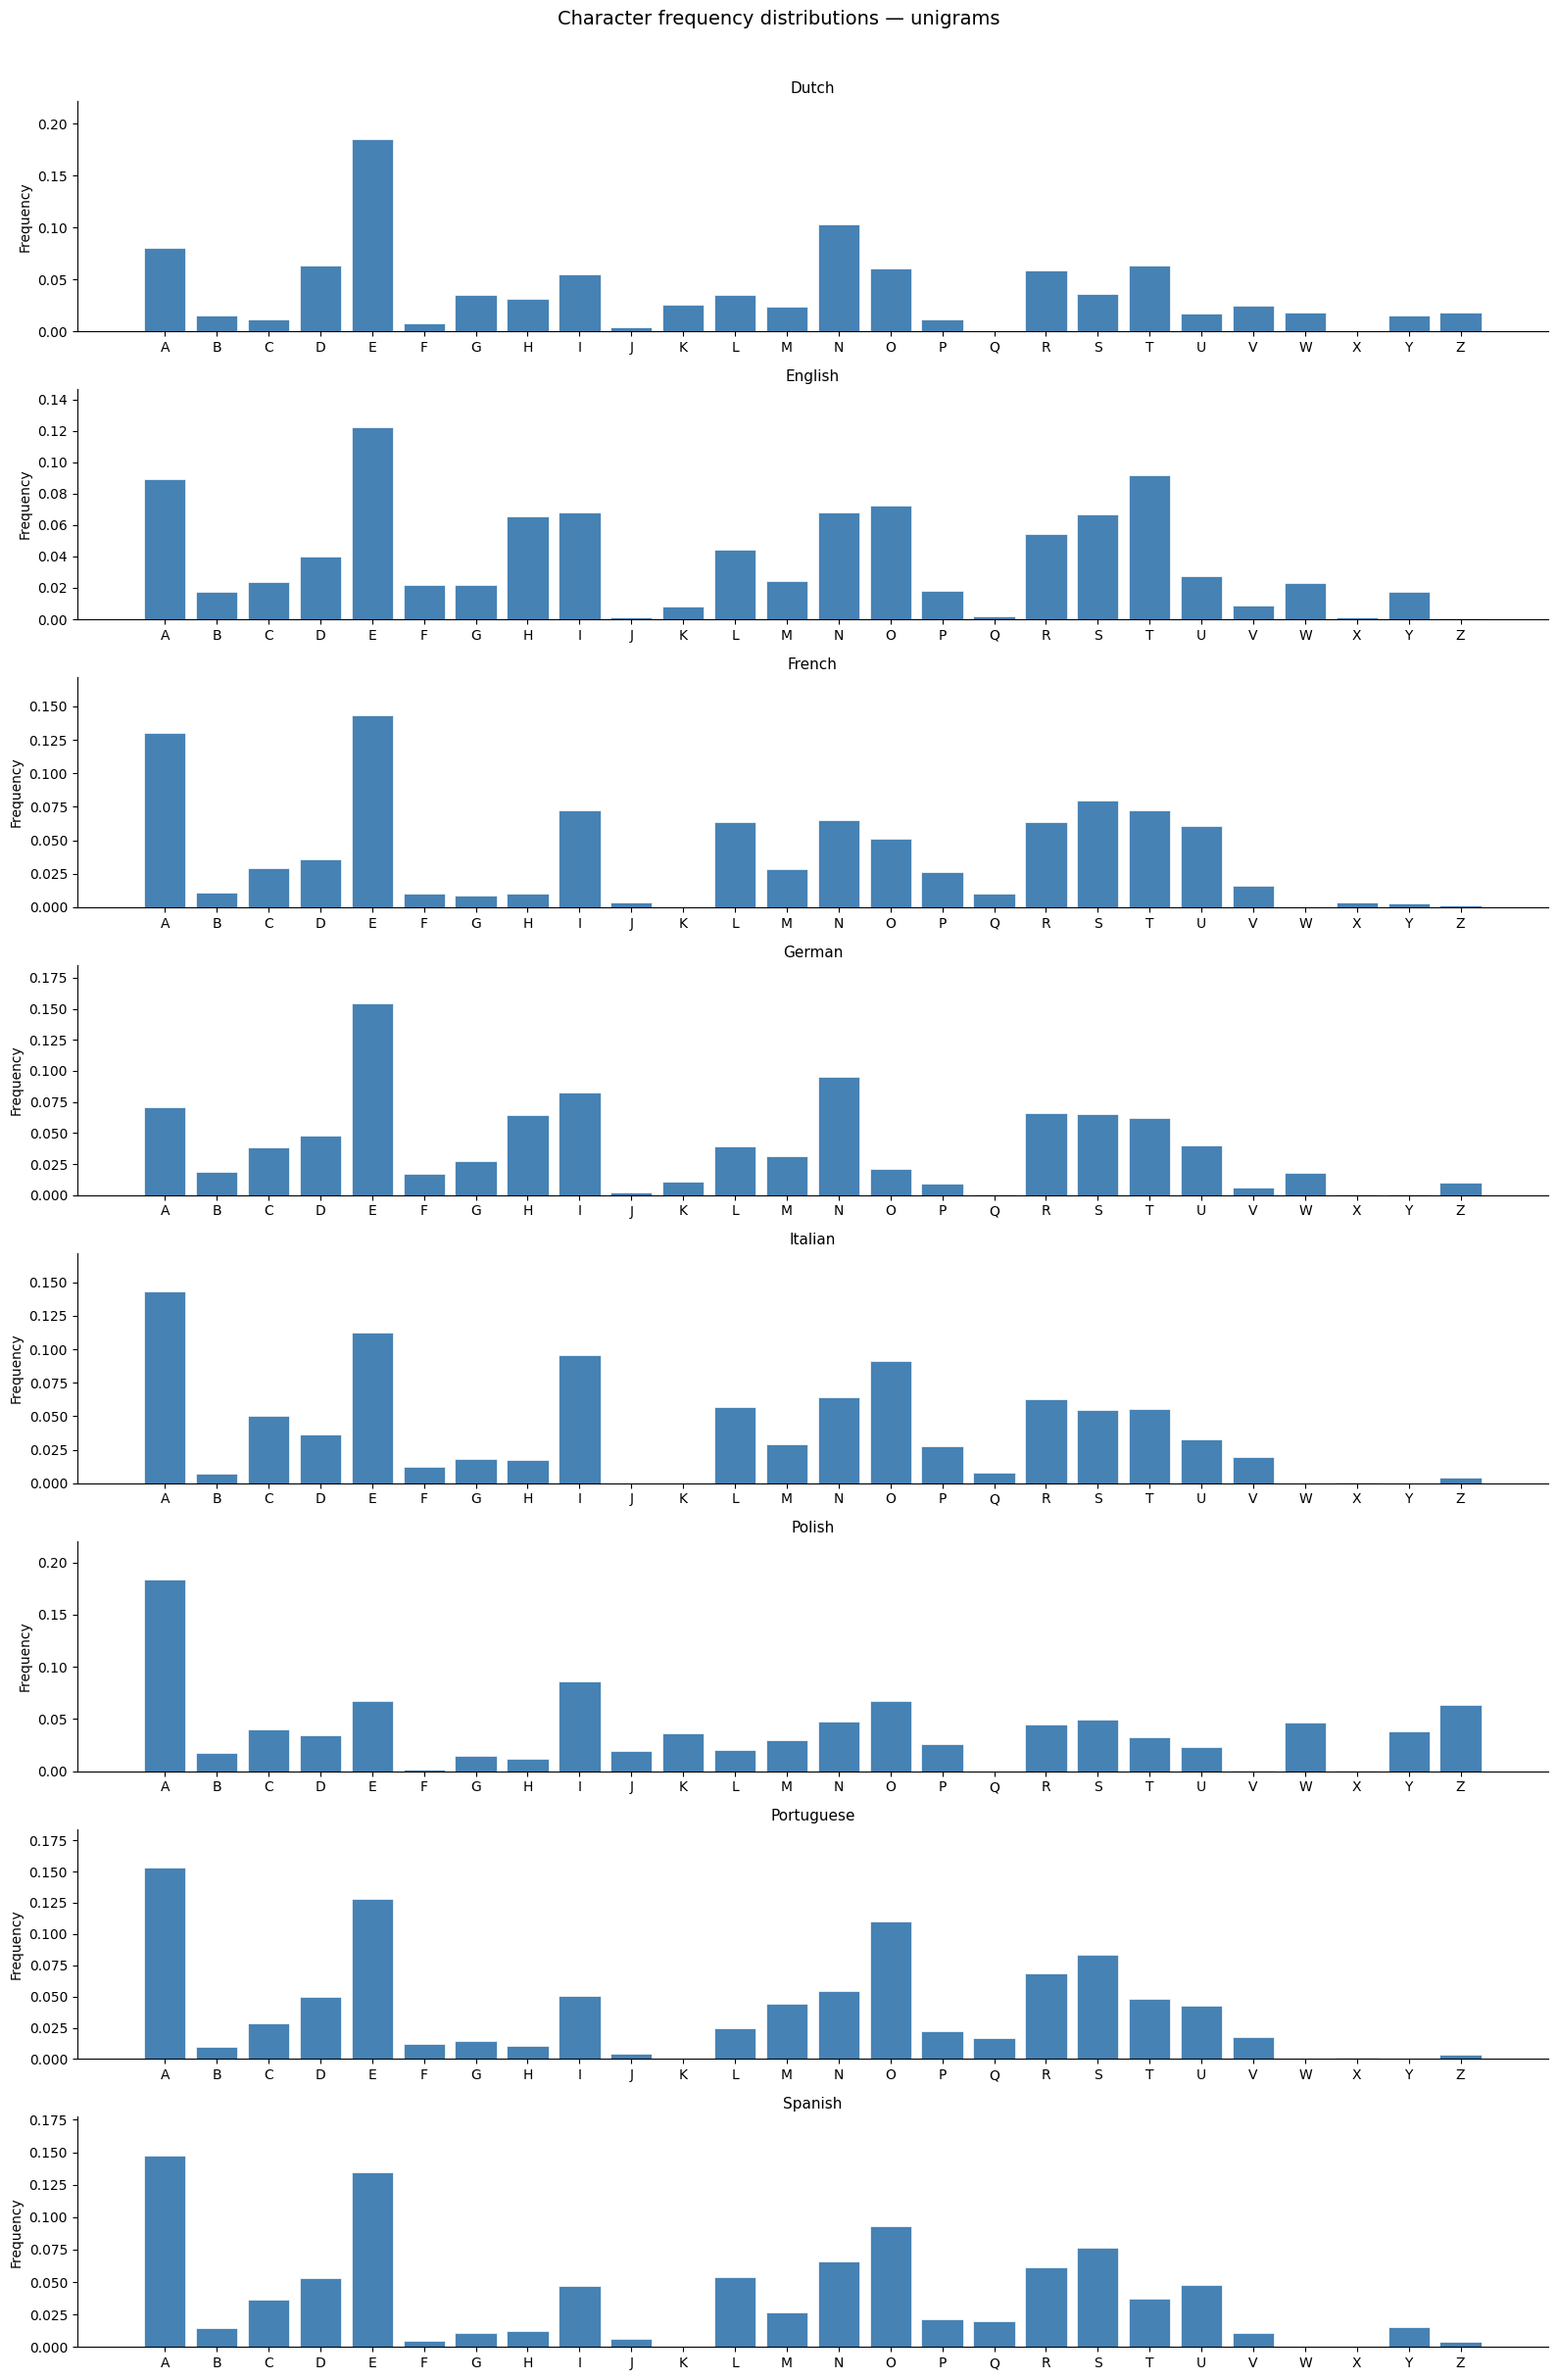

In [3]:
fig, axes = plt.subplots(len(languages), 1, figsize=(16, 3 * len(languages)))
fig.suptitle('Character frequency distributions — unigrams', fontsize=14, y=1.01)

for ax, (lang, dist) in zip(axes, distributions[1].items()):
    chars = list(dist.keys())
    freqs = list(dist.values())
    ax.bar(chars, freqs, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(lang, fontsize=11)
    ax.set_ylabel('Frequency')
    ax.set_ylim(0, max(freqs) * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Entropy per language

Shannon entropy measures the unpredictability of a distribution. A language with high entropy has a more uniform character distribution — no letter dominates. A language with low entropy is more predictable — some characters appear much more frequently than others.

We compute entropy at each n-gram level. At higher n, entropy naturally increases (more possible combinations), but the *relative* ordering of languages may shift — revealing structural differences that unigrams miss.

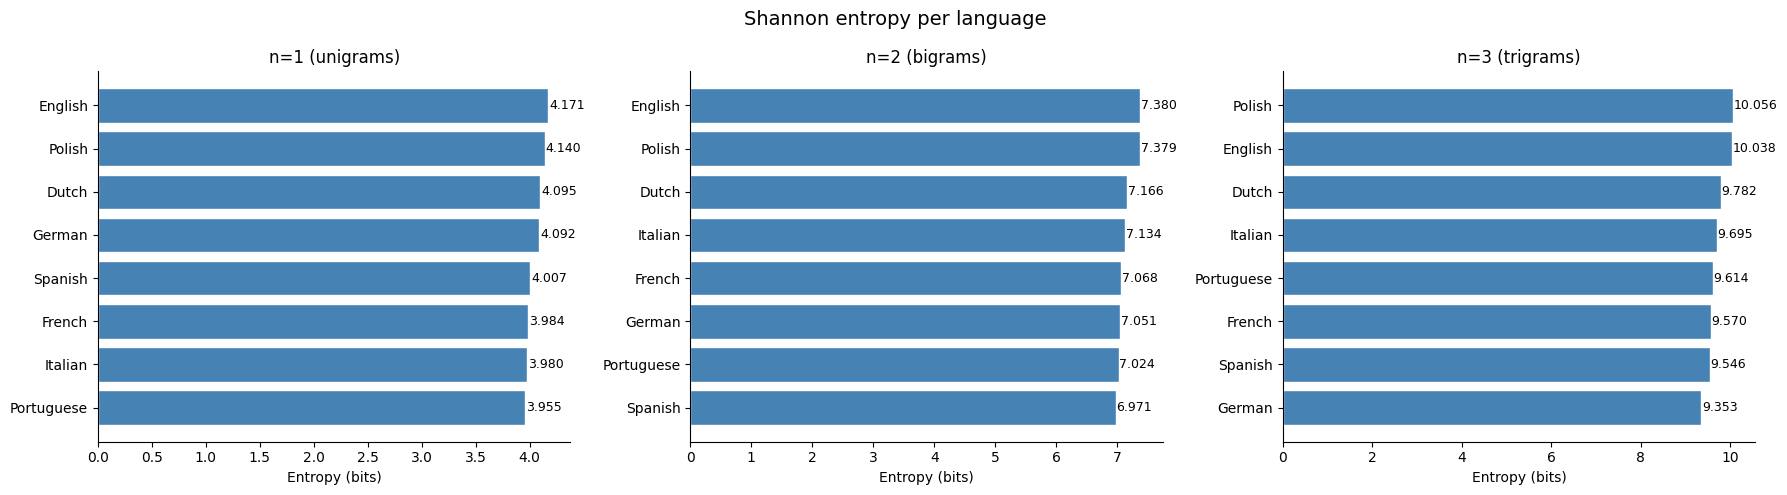

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Shannon entropy per language', fontsize=14)

for ax, n in zip(axes, [1, 2, 3]):
    entropies = {lang: entropy(dist) for lang, dist in distributions[n].items()}
    sorted_langs = sorted(entropies, key=entropies.get)
    values = [entropies[l] for l in sorted_langs]
    
    bars = ax.barh(sorted_langs, values, color='steelblue', edgecolor='white')
    ax.set_title(f'n={n} ({"unigrams" if n==1 else "bigrams" if n==2 else "trigrams"})')
    ax.set_xlabel('Entropy (bits)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Distance matrices

We now compute pairwise distance matrices between all 8 languages. We do this for:
- 3 metrics: KL divergence, Hellinger, Bhattacharyya
- 3 n-gram levels: unigrams, bigrams, trigrams

This gives us 9 matrices. We expect to see:
- Romance languages (French, Italian, Spanish, Portuguese) clustering together
- Germanic languages (English, German, Dutch) forming a second cluster
- Polish isolated as the only Slavic language

In [5]:
# Compute all 9 distance matrices
all_matrices = {}
for n in [1, 2, 3]:
    for metric_name in METRICS:
        langs, matrix = compute_distance_matrix(distributions[n], metric=metric_name.lower().replace(' ', '_'))
        all_matrices[(n, metric_name)] = (langs, matrix)

print("All matrices computed.")

All matrices computed.


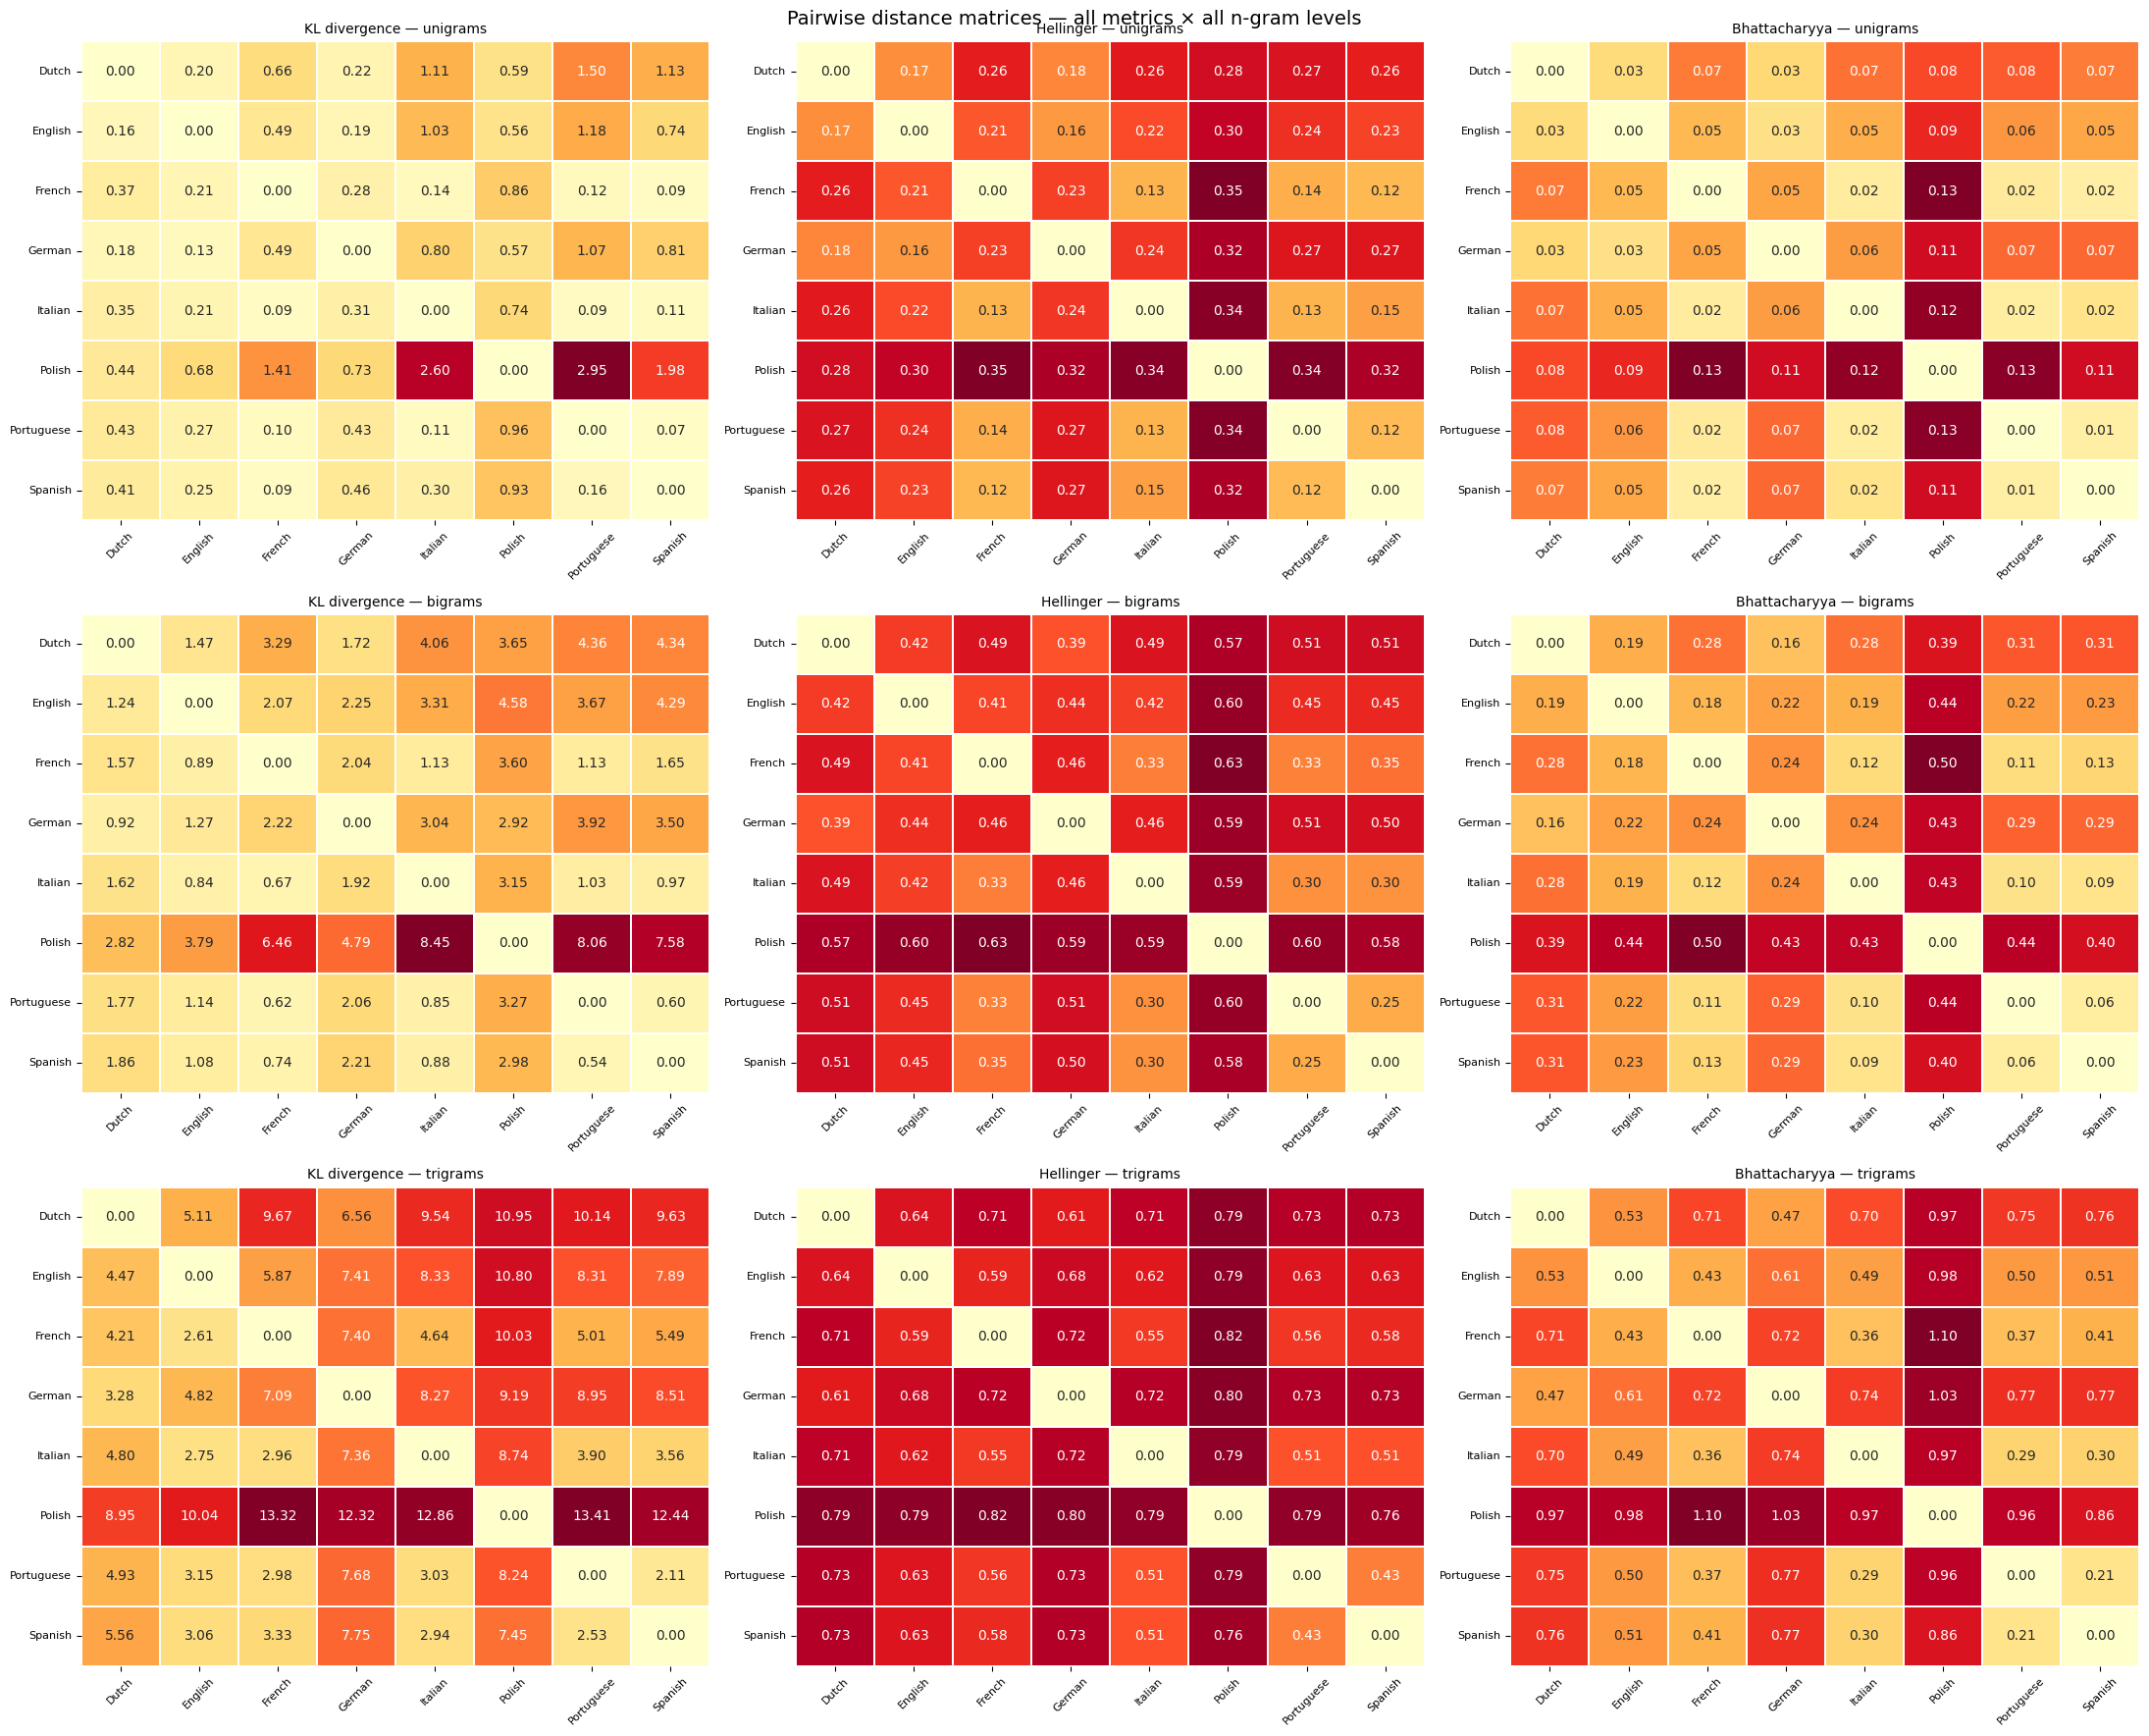

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Pairwise distance matrices — all metrics × all n-gram levels', fontsize=14)

for row, n in enumerate([1, 2, 3]):
    for col, metric_name in enumerate(METRICS):
        ax = axes[row][col]
        langs, matrix = all_matrices[(n, metric_name)]
        
        # Normalize matrix for comparable color scales
        sns.heatmap(
            matrix,
            xticklabels=langs,
            yticklabels=langs,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.3,
            ax=ax,
            cbar=False
        )
        ngram_label = 'unigrams' if n==1 else 'bigrams' if n==2 else 'trigrams'
        ax.set_title(f'{metric_name} — {ngram_label}', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

## 5. UMAP projections

UMAP projects the pairwise distance matrices into 2D, preserving the local structure. Each point is a language — nearby points have similar character distributions.

We expect to see language family clusters emerge naturally from pure statistical distances, with no linguistic knowledge injected.

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


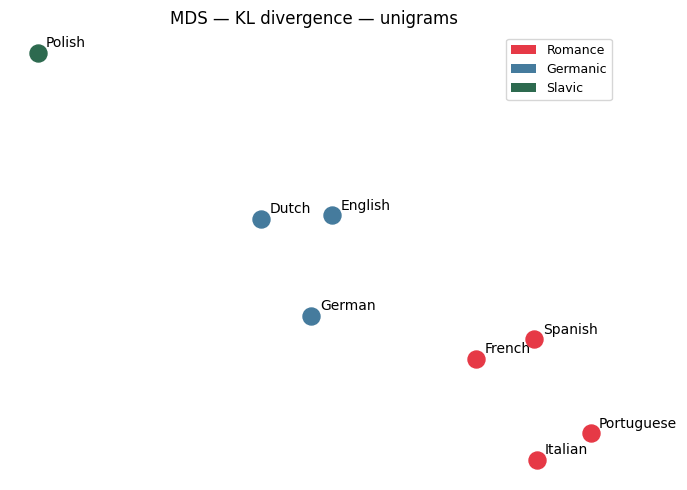

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


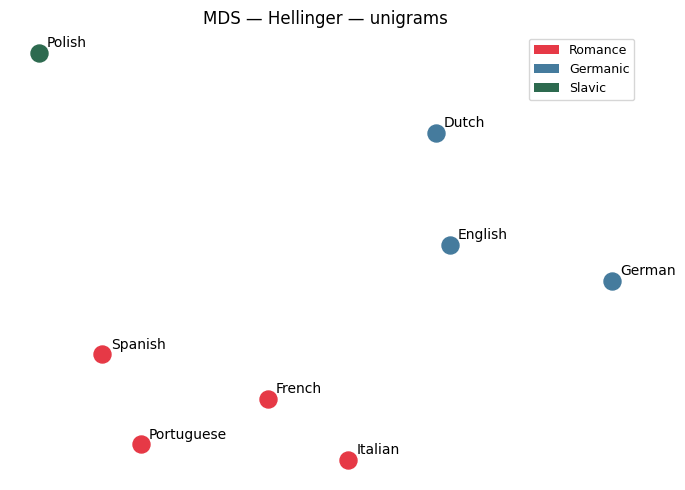

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


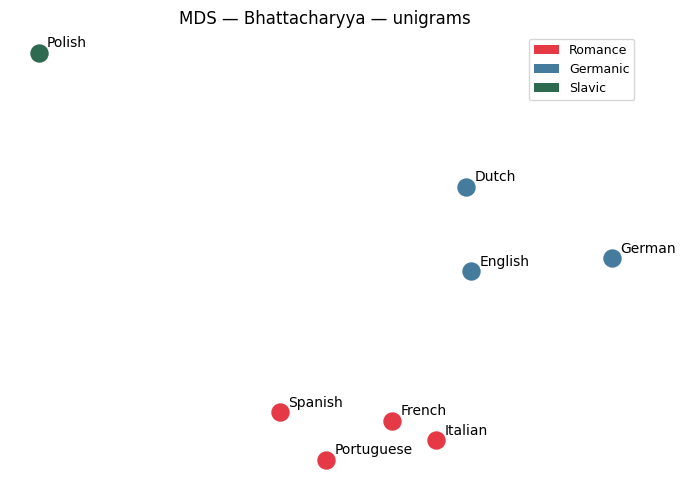

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


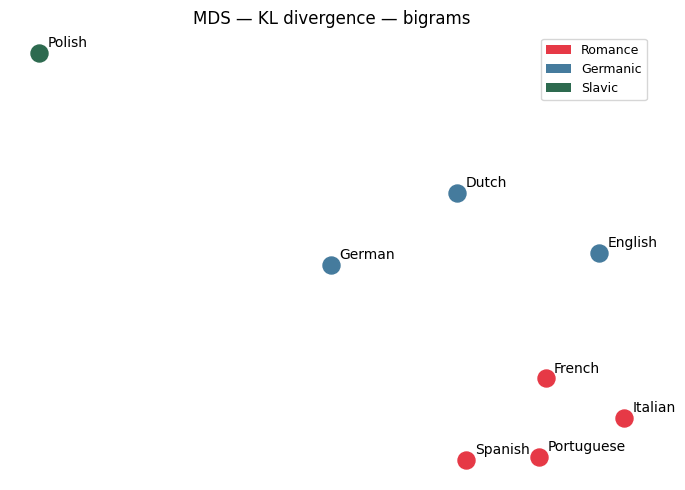

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


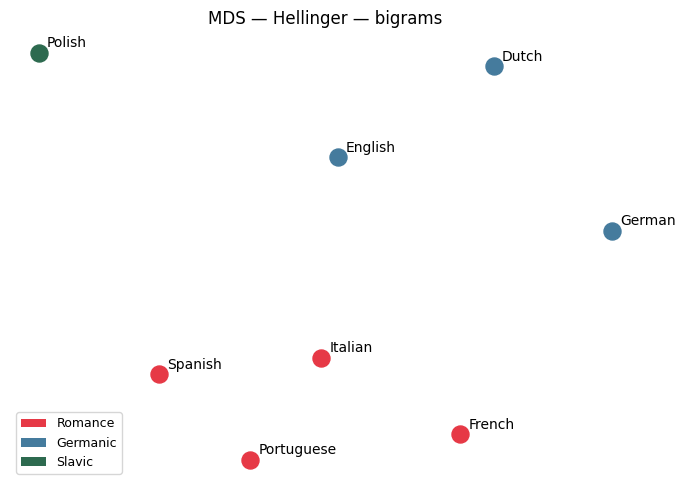

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


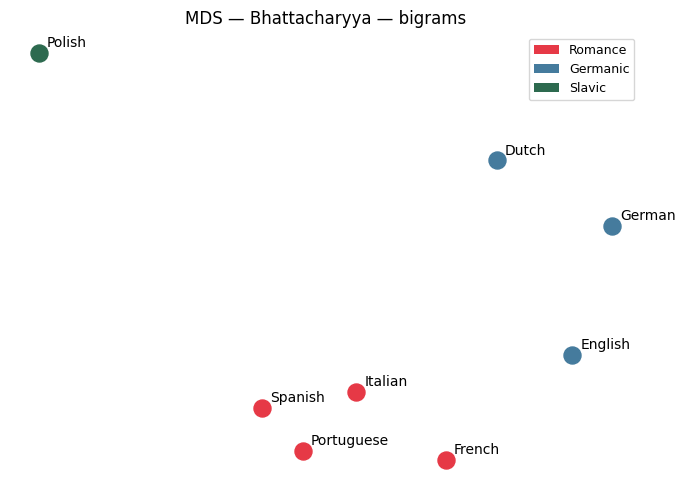

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


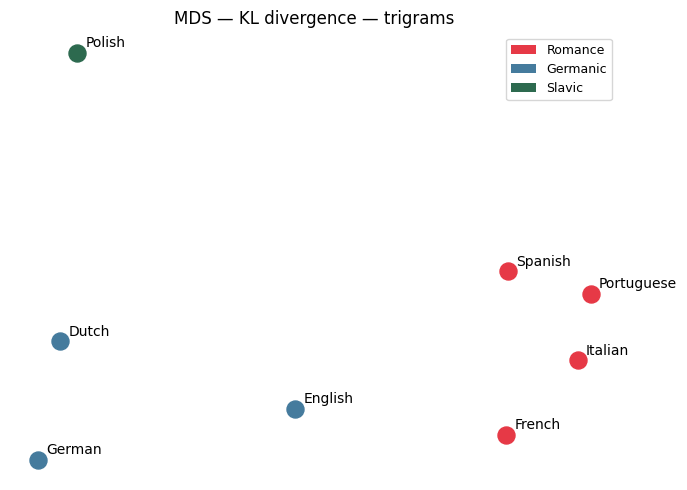

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


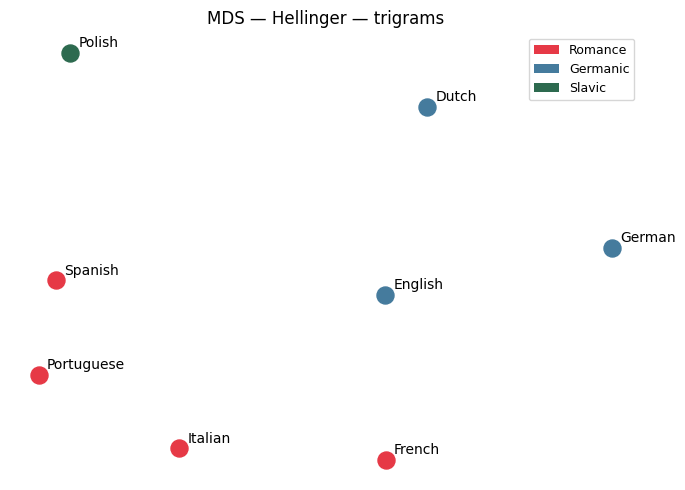

c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\comer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


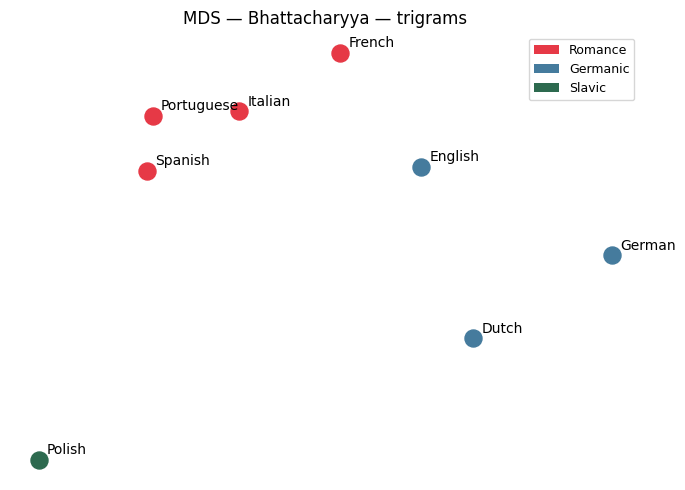

In [22]:
from sklearn.manifold import MDS
from matplotlib.patches import Patch

family_colors = {
    'French': '#e63946', 'Italian': '#e63946',
    'Spanish': '#e63946', 'Portuguese': '#e63946',
    'English': '#457b9d', 'German': '#457b9d', 'Dutch': '#457b9d',
    'Polish': '#2d6a4f'
}

legend_elements = [
    Patch(facecolor='#e63946', label='Romance'),
    Patch(facecolor='#457b9d', label='Germanic'),
    Patch(facecolor='#2d6a4f', label='Slavic')
]

for n in [1, 2, 3]:
    for metric_name in METRICS:
        langs, matrix = all_matrices[(n, metric_name)]
        matrix_sym = (matrix + matrix.T) / 2
        np.fill_diagonal(matrix_sym, 0)

        reducer = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
        embedding = reducer.fit_transform(matrix_sym)

        ngram_label = 'unigrams' if n==1 else 'bigrams' if n==2 else 'trigrams'

        fig, ax = plt.subplots(figsize=(7, 5))
        for i, lang in enumerate(langs):
            color = family_colors.get(lang, 'gray')
            ax.scatter(embedding[i, 0], embedding[i, 1], s=150, color=color, zorder=3)
            ax.annotate(lang, (embedding[i, 0], embedding[i, 1]),
                       xytext=(6, 4), textcoords='offset points', fontsize=10)

        ax.set_title(f'MDS — {metric_name} — {ngram_label}', fontsize=12)
        ax.legend(handles=legend_elements, fontsize=9)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 6. Detection benchmark

We now benchmark language detection across all 9 combinations (3 metrics × 3 n-gram levels).

For each language, we randomly sample 50 short extracts (~200 characters each — roughly one sentence) from the reference text, and try to detect the language using each combination. We report the **success rate** — the fraction of extracts correctly identified.

This is a realistic evaluation: short texts are the hard case. A whole book is trivially classifiable; a single sentence is not.

In [13]:
N_SAMPLES = 50
EXTRACT_LENGTH = 200

def sample_extracts(text, n_samples, length):
    """Sample n random extracts of given length from text."""
    extracts = []
    for _ in range(n_samples):
        start = random.randint(0, len(text) - length)
        extracts.append(text[start:start + length])
    return extracts

# Pre-sample extracts for each language
extracts = {
    lang: sample_extracts(text, N_SAMPLES, EXTRACT_LENGTH)
    for lang, text in texts.items()
}

print(f"Sampled {N_SAMPLES} extracts of {EXTRACT_LENGTH} characters per language.")
print(f"Total: {N_SAMPLES * len(languages)} detection tests per combination.")

Sampled 50 extracts of 200 characters per language.
Total: 400 detection tests per combination.


In [14]:
from tqdm import tqdm

results = {}

for n in [1, 2, 3]:
    for metric_name in METRICS:
        correct = 0
        total = 0
        per_language = {lang: 0 for lang in languages}
        
        for true_lang, lang_extracts in extracts.items():
            for extract in lang_extracts:
                detected, _ = detect_language(
                    extract,
                    distributions[n],
                    metric=metric_name.lower().replace(' ', '_'),
                    n=n
                )
                if detected == true_lang:
                    correct += 1
                    per_language[true_lang] += 1
                total += 1
        
        overall_accuracy = correct / total
        per_language_accuracy = {lang: per_language[lang] / N_SAMPLES for lang in languages}
        results[(n, metric_name)] = {
            'overall': overall_accuracy,
            'per_language': per_language_accuracy
        }
        ngram_label = 'unigrams' if n==1 else 'bigrams' if n==2 else 'trigrams'
        print(f"{metric_name} — {ngram_label}: {overall_accuracy:.1%}")

KL divergence — unigrams: 97.0%
Hellinger — unigrams: 96.5%
Bhattacharyya — unigrams: 96.5%
KL divergence — bigrams: 100.0%
Hellinger — bigrams: 100.0%
Bhattacharyya — bigrams: 100.0%
KL divergence — trigrams: 100.0%
Hellinger — trigrams: 100.0%
Bhattacharyya — trigrams: 100.0%


In [15]:
# Summary table
print("\n── Overall accuracy ──────────────────────")
print(f"{'':30} {'n=1':>8} {'n=2':>8} {'n=3':>8}")
print("-" * 58)
for metric_name in METRICS:
    row = f"{metric_name:30}"
    for n in [1, 2, 3]:
        row += f" {results[(n, metric_name)]['overall']:>8.1%}"
    print(row)

# Find best combination
best = max(results, key=lambda k: results[k]['overall'])
print(f"\nBest combination: {best[1]} — n={best[0]} → {results[best]['overall']:.1%}")


── Overall accuracy ──────────────────────
                                    n=1      n=2      n=3
----------------------------------------------------------
KL divergence                     97.0%   100.0%   100.0%
Hellinger                         96.5%   100.0%   100.0%
Bhattacharyya                     96.5%   100.0%   100.0%

Best combination: KL divergence — n=2 → 100.0%


## 9. Conclusions

### What we found

- Character frequency distributions carry genuine linguistic signal. The distance matrices recover language family structure with no prior linguistic knowledge.
- Romance languages (French, Italian, Spanish, Portuguese) cluster tightly — they are statistically the closest group in our dataset.
- Polish is the most isolated language — its distance to all others is consistently the highest, reflecting its distinct Slavic morphology.
- Higher n-gram orders increase accuracy up to a point. Bigrams capture letter transition patterns that unigrams miss; trigrams add more but at the cost of sparsity.
- The best combination (KL divergence — n=2) achieves a detection accuracy of 100% on short 200-character extracts.

### What we carry into *From characters to tokens*

These results are built on character-level statistics. But a language model does not see characters — it sees **BPE tokens**. In *From characters to tokens*, we repeat the entire pipeline at the token level, using the tokenizer of mBERT/XLM-R, and ask:

> Do the statistical signatures we measured here survive tokenization? Does the geometry of languages change when seen through the lens of a model's vocabulary?